## 03 - Dimensionality Reduction & Clustering  
Mục tiêu: Giảm chiều bằng PCA, UMAP, sau đó phân cụm bằng k-means

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

feat = pd.read_parquet('data/user_features.parquet')
with open('data/feature_cols_user.json') as f:
    cols = json.load(f)

In [58]:
# Loại nhóm primary_* (one-hot ngành hàng chủ đạo) khỏi vector clustering - xem lý do ở trên
cluster_feature_cols = [c for c in cols['behavior_feature_cols'] if not c.startswith('primary_')]
department_signal_cols = ['department_diversity', 'produce_share', 'dairy_share']  # phần department còn giữ lại (liên tục, không one-hot)

print('Số khách hàng:', feat.shape[0])
print('Số chiều dùng để clustering:', len(cluster_feature_cols))
print(cluster_feature_cols)

Số khách hàng: 70268
Số chiều dùng để clustering: 15
['log_max_order_number', 'log_avg_basket_size', 'avg_reorder_rate', 'log_avg_days_between_orders', 'weekend_ratio', 'startweek_ratio', 'hb_night', 'hb_morning', 'hb_noon', 'hb_afternoon', 'hb_evening', 'hb_late_evening', 'department_diversity', 'produce_share', 'dairy_share']


In [61]:
from sklearn.preprocessing import StandardScaler

X = feat[cluster_feature_cols].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('X_scaled shape:', X_scaled.shape)

X_scaled shape: (70268, 15)


# 1. PCA

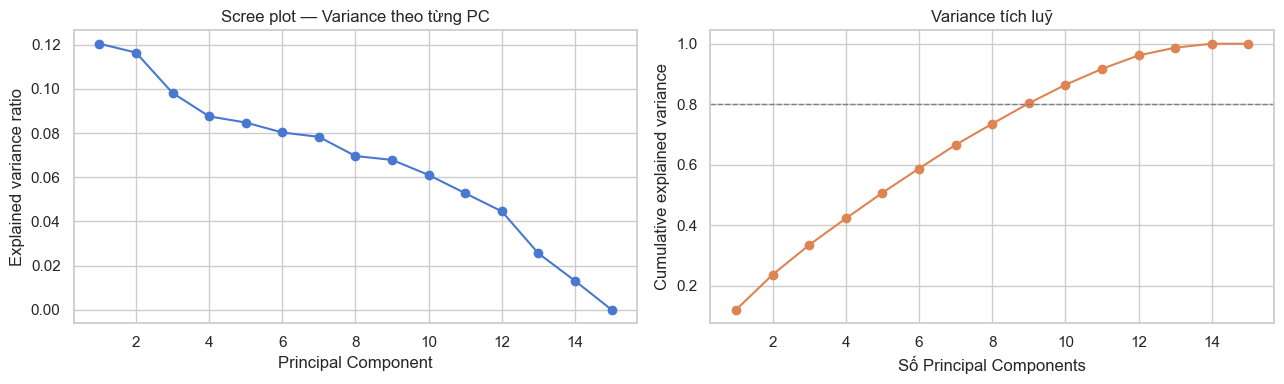

8 PC đầu giải thích 73.5% phương sai
10 PC đầu giải thích 86.4% phương sai
12 PC đầu giải thích 96.1% phương sai


In [62]:
from sklearn.decomposition import PCA

n_dims = X_scaled.shape[1]
pca_full = PCA(n_components=n_dims, random_state=42).fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(range(1, n_dims+1), pca_full.explained_variance_ratio_, marker='o')
axes[0].set_title('Scree plot — Variance theo từng PC')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Explained variance ratio')

axes[1].plot(range(1, n_dims+1), cum_var, marker='o', color='#DD8452')
axes[1].axhline(0.8, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Variance tích luỹ')
axes[1].set_xlabel('Số Principal Components'); axes[1].set_ylabel('Cumulative explained variance')
plt.tight_layout()
plt.show()

for n in [8, 10, 12]:
    print(f'{n} PC đầu giải thích {cum_var[n-1]*100:.1f}% phương sai')

**Nhận xét**: phương sai giải thích tăng khá đều

In [63]:
pca = PCA(n_components=10, random_state=42).fit(X_scaled)
X_pca = pca.transform(X_scaled)
print('X_pca shape:', X_pca.shape)

X_pca shape: (70268, 10)


1.1 Loading của PC1 và PC2 - thành phần nào chi phối các trục chính

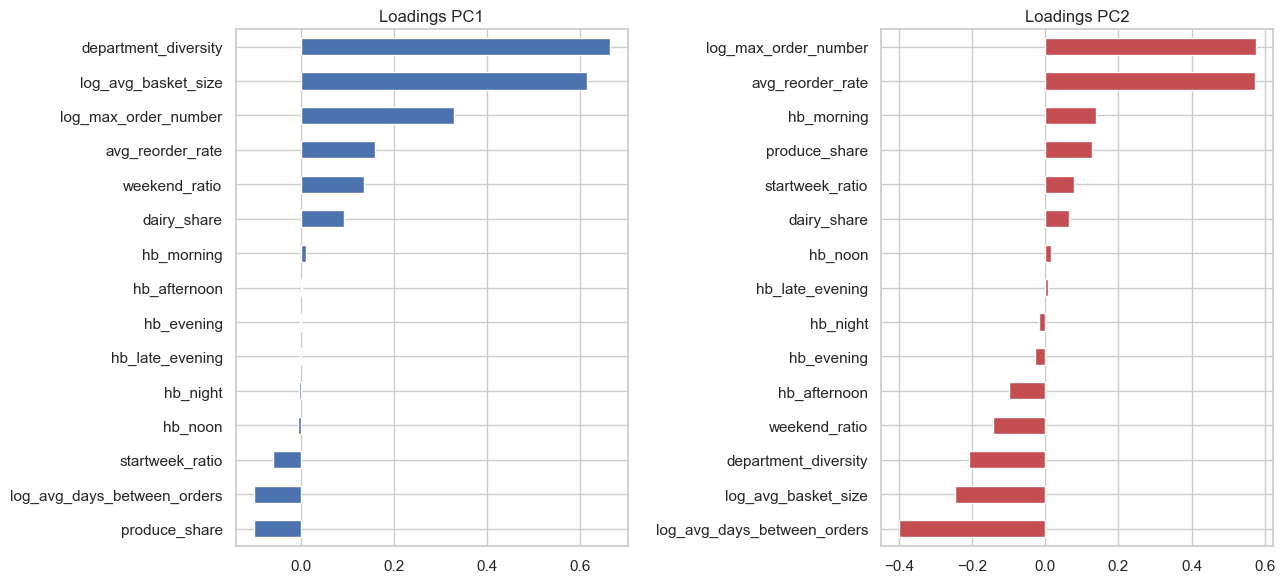

In [64]:
loadings = pd.DataFrame(pca.components_[:2].T, index=cluster_feature_cols, columns=['PC1', 'PC2'])
fig, axes = plt.subplots(1, 2, figsize=(13,6))
loadings['PC1'].sort_values().plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Loadings PC1')
loadings['PC2'].sort_values().plot(kind='barh', ax=axes[1], color='#C44E52')
axes[1].set_title('Loadings PC2')
plt.tight_layout()
plt.show()

 + PC1 gắn liền với nhóm tần suất/thâm niên (`log_max_order_number`, `avg_reorder_rate`, `log_avg_days_between_orders`)  
 + PC2 nghiêng về nhịp thời gian mua sắm (weekend/startweek/khung giờ). Department (`department_diversity`, `produce_share`, `dairy_share`) 

# 2 UMAP

In [65]:
import os
import umap

In [66]:
print(X_pca.shape)
print(X_pca.dtype)
print(X_pca.nbytes / 1024**2, "MB")

(70268, 10)
float64
5.36102294921875 MB


In [67]:
import os
import umap

n_pca = X_pca.shape[1]
precomputed_path = f'data/X_umap_user_precomputed_pca{n_pca}.npy'
if os.path.exists(precomputed_path):
    X_umap = np.load(precomputed_path)
    print(f'Da tai UMAP embedding tinh san (user-level, PCA={n_pca}):', X_umap.shape)
else:
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, n_jobs=1)
    X_umap = reducer.fit_transform(X_pca)
    np.save(precomputed_path, X_umap)
    print('X_umap shape:', X_umap.shape)

X_umap shape: (70268, 2)


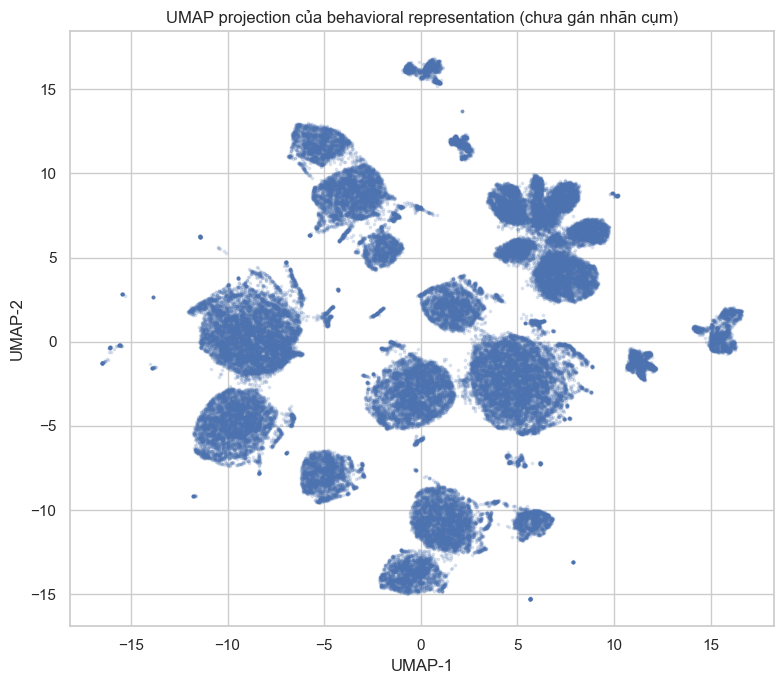

In [68]:
fig, ax = plt.subplots(figsize=(8,7))
ax.scatter(X_umap[:,0], X_umap[:,1], s=3, alpha=0.15, color='#4C72B0')
ax.set_title('UMAP projection của behavioral representation (chưa gán nhãn cụm)')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
plt.tight_layout()
plt.show()

# 3 chọn số cụm K

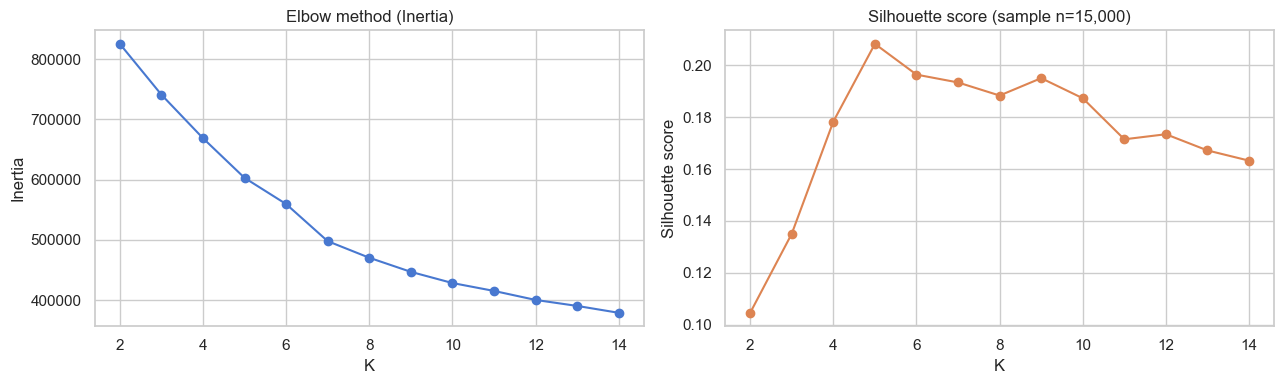

K=2: silhouette=0.1046
K=3: silhouette=0.1350
K=4: silhouette=0.1783
K=5: silhouette=0.2083
K=6: silhouette=0.1964
K=7: silhouette=0.1934
K=8: silhouette=0.1883
K=9: silhouette=0.1950
K=10: silhouette=0.1873
K=11: silhouette=0.1715
K=12: silhouette=0.1734
K=13: silhouette=0.1672
K=14: silhouette=0.1632


In [69]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 15)
inertias, sils = [], []
sample_idx = np.random.RandomState(42).choice(len(X_pca), 15000, replace=False)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_pca)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_pca[sample_idx], km.labels_[sample_idx]))

fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].plot(list(ks), inertias, marker='o')
axes[0].set_title('Elbow method (Inertia)')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(ks), sils, marker='o', color='#DD8452')
axes[1].set_title('Silhouette score (sample n=15,000)')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette score')
plt.tight_layout()
plt.show()

for k, s in zip(ks, sils):
    print(f'K={k}: silhouette={s:.4f}')

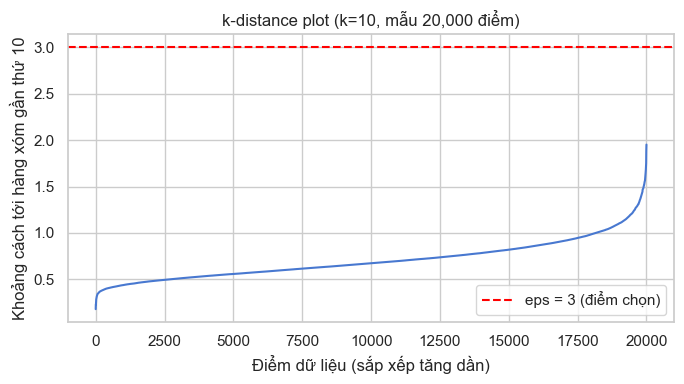

Percentiles k-distance: [0.67 0.99 1.1  1.39]


In [40]:
from sklearn.neighbors import NearestNeighbors

min_samples = 10
sub_idx = np.random.RandomState(0).choice(len(X_pca), 20000, replace=False)
nn = NearestNeighbors(n_neighbors=min_samples).fit(X_pca[sub_idx])
dist, _ = nn.kneighbors(X_pca[sub_idx])
kdist = np.sort(dist[:, -1])

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(kdist)
ax.axhline(3, color='red', linestyle='--', label='eps = 3 (điểm chọn)')
ax.set_title(f'k-distance plot (k={min_samples}, mẫu 20,000 điểm)')
ax.set_xlabel('Điểm dữ liệu (sắp xếp tăng dần)')
ax.set_ylabel(f'Khoảng cách tới hàng xóm gần thứ {min_samples}')
ax.legend()
plt.tight_layout()
plt.show()

print('Percentiles k-distance:', np.percentile(kdist, [50, 90, 95, 99]).round(2))

In [77]:
K = 5
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_pca)
feat['cluster'] = kmeans.labels_
print(feat['cluster'].value_counts().sort_index())
print('Silhouette (full, sample 15k):', round(silhouette_score(X_pca[sample_idx], kmeans.labels_[sample_idx]), 4))

cluster
0    12998
1    23472
2     3874
3    18769
4    11155
Name: count, dtype: int64
Silhouette (full, sample 15k): 0.2083


In [73]:
K = 6
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_pca)
feat['cluster'] = kmeans.labels_
print(feat['cluster'].value_counts().sort_index())
print('Silhouette (full, sample 15k):', round(silhouette_score(X_pca[sample_idx], kmeans.labels_[sample_idx]), 4))

cluster
0    15290
1    17279
2     1410
3     9677
4     9272
5    17340
Name: count, dtype: int64
Silhouette (full, sample 15k): 0.1964


In [75]:
K = 7
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_pca)
feat['cluster'] = kmeans.labels_
print(feat['cluster'].value_counts().sort_index())
print('Silhouette (full, sample 15k):', round(silhouette_score(X_pca[sample_idx], kmeans.labels_[sample_idx]), 4))

cluster
0     9480
1    16096
2    15157
3     1410
4    16723
5     2381
6     9021
Name: count, dtype: int64
Silhouette (full, sample 15k): 0.1934


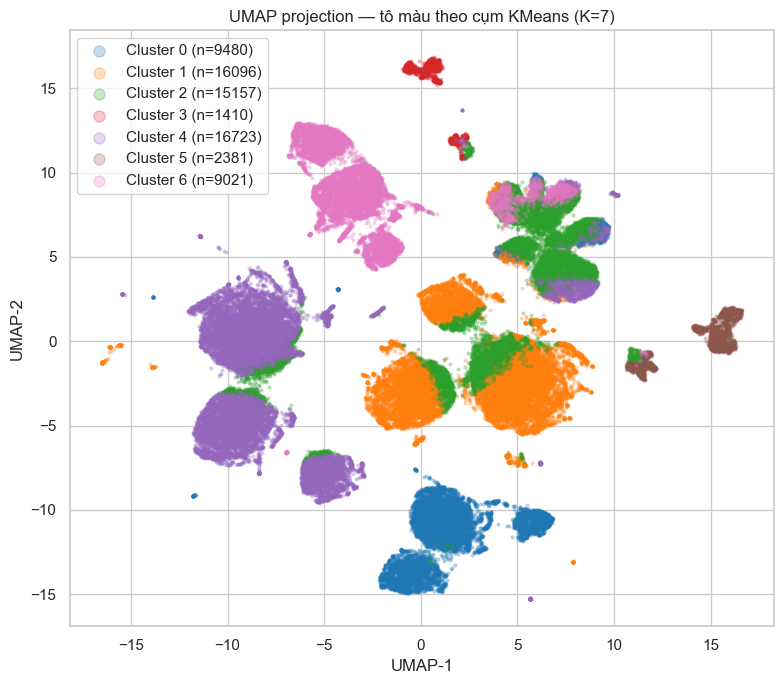

In [76]:
palette = sns.color_palette('tab10', K)
fig, ax = plt.subplots(figsize=(8,7))
for c in range(K):
    mask = feat['cluster'] == c
    ax.scatter(X_umap[mask,0], X_umap[mask,1], s=4, alpha=0.25, color=palette[c], label=f'Cluster {c} (n={mask.sum()})')
ax.set_title('UMAP projection — tô màu theo cụm KMeans (K=7)')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.legend(markerscale=4, loc='best')
plt.tight_layout()
plt.show()

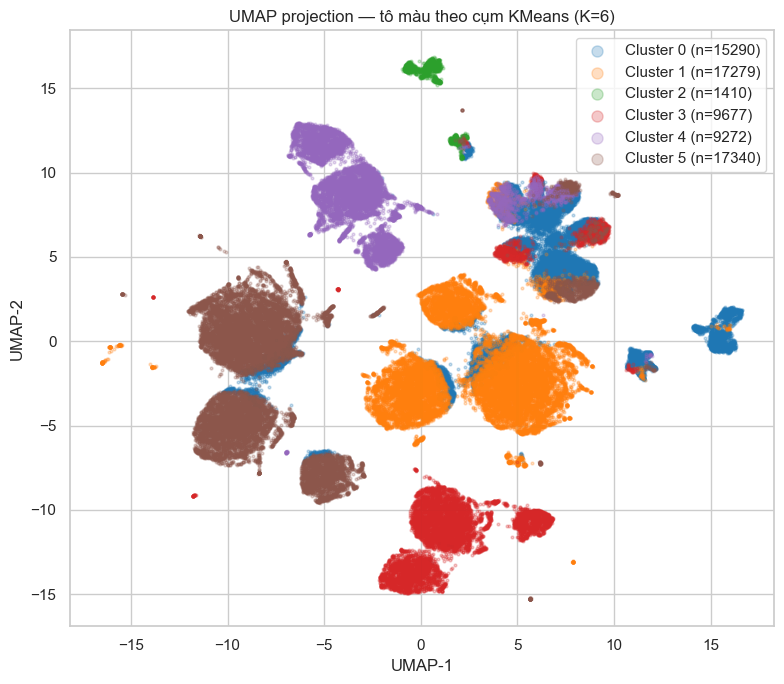

In [74]:
palette = sns.color_palette('tab10', K)
fig, ax = plt.subplots(figsize=(8,7))
for c in range(K):
    mask = feat['cluster'] == c
    ax.scatter(X_umap[mask,0], X_umap[mask,1], s=4, alpha=0.25, color=palette[c], label=f'Cluster {c} (n={mask.sum()})')
ax.set_title('UMAP projection — tô màu theo cụm KMeans (K=6)')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.legend(markerscale=4, loc='best')
plt.tight_layout()
plt.show()

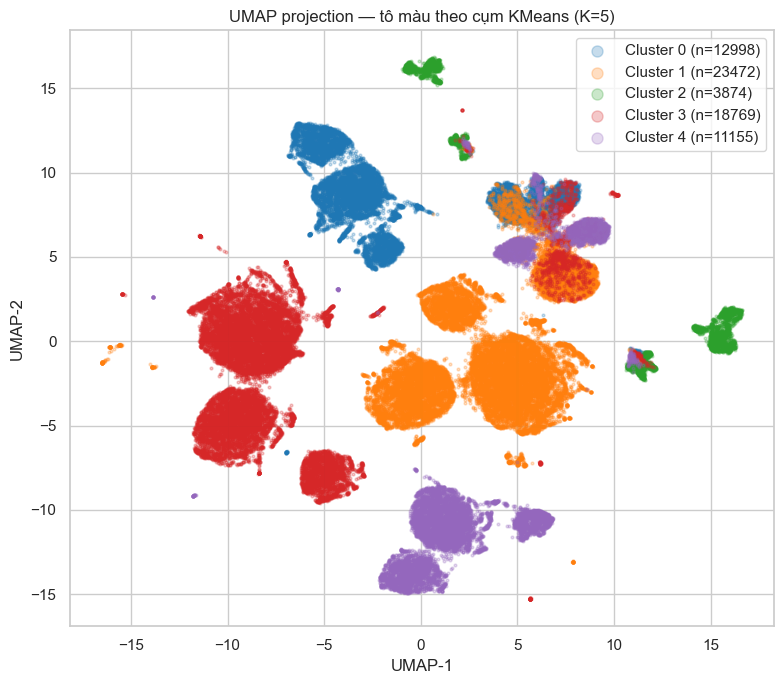

In [72]:
palette = sns.color_palette('tab10', K)
fig, ax = plt.subplots(figsize=(8,7))
for c in range(K):
    mask = feat['cluster'] == c
    ax.scatter(X_umap[mask,0], X_umap[mask,1], s=4, alpha=0.25, color=palette[c], label=f'Cluster {c} (n={mask.sum()})')
ax.set_title('UMAP projection — tô màu theo cụm KMeans (K=5)')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.legend(markerscale=4, loc='best')
plt.tight_layout()
plt.show()

# 6. Cluster từng phân khúc

In [80]:
profile_cols = ['max_order_number', 'avg_basket_size', 'avg_reorder_rate', 'avg_days_between_orders',
                'weekend_ratio', 'startweek_ratio'] + department_signal_cols + ['is_new_customer']
profile = feat.groupby('cluster')[profile_cols].mean()
pd.set_option('display.max_columns', 20)
profile.round(3).T

cluster,0,1,2,3,4
max_order_number,20.75,16.87,15.77,14.00,15.22
avg_basket_size,10.23,10.20,10.34,10.04,9.92
avg_reorder_rate,0.61,0.56,0.56,0.54,0.55
avg_days_between_orders,11.27,12.36,12.39,13.02,12.52
weekend_ratio,0.28,0.32,0.33,0.33,0.31
startweek_ratio,0.19,0.17,0.15,0.16,0.16
department_diversity,0.46,0.45,0.45,0.44,0.46
produce_share,0.29,0.28,0.30,0.28,0.28
dairy_share,0.17,0.16,0.16,0.16,0.16
is_new_customer,0.05,0.06,0.06,0.07,0.06


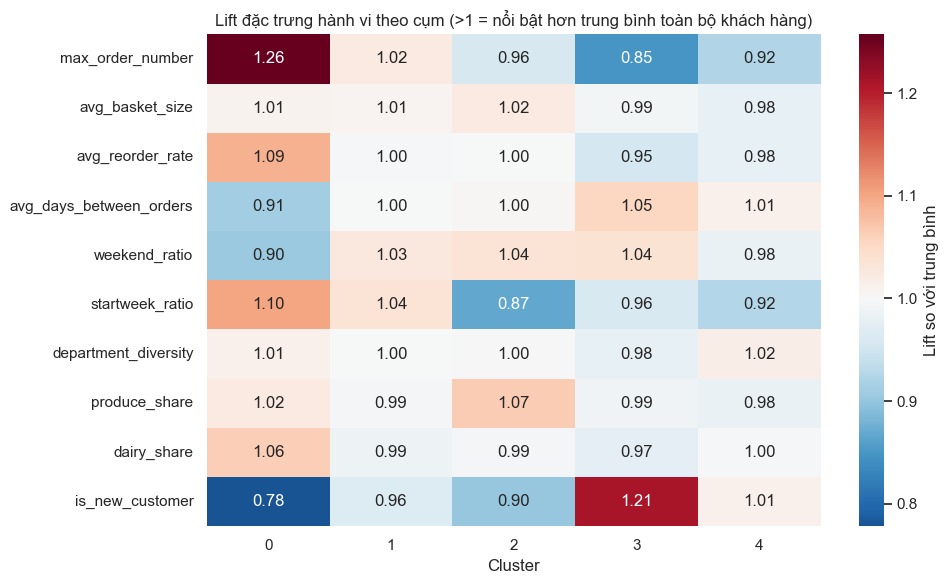

In [82]:
overall_mean = feat[profile_cols].mean()
lift = profile.div(overall_mean, axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(lift.T, cmap='RdBu_r', center=1, annot=True, fmt='.2f', ax=ax, cbar_kws={'label':'Lift so với trung bình'})
ax.set_title('Lift đặc trưng hành vi theo cụm (>1 = nổi bật hơn trung bình toàn bộ khách hàng)')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

In [84]:
cluster_sizes = feat['cluster'].value_counts().sort_index()
print('=== Đặc trưng nổi bật nhất mỗi cụm (theo lift) ===\n')
for c in range(K):
    top3 = lift.loc[c].drop('is_new_customer', errors='ignore').abs().sort_values(ascending=False).head(4)
    print(f'Cluster {c} (n={cluster_sizes[c]:,}, {cluster_sizes[c]/len(feat)*100:.1f}%):')
    for feat_name in top3.index:
        print(f'    {feat_name:24s} lift={lift.loc[c, feat_name]:.2f}   giá trị TB={profile.loc[c, feat_name]:.2f}')
    print(f'    is_new_customer lift={lift.loc[c,"is_new_customer"]:.2f} ({profile.loc[c,"is_new_customer"]*100:.1f}% là khách mới)')
    print()

=== Đặc trưng nổi bật nhất mỗi cụm (theo lift) ===

Cluster 0 (n=12,998, 18.5%):
    max_order_number         lift=1.26   giá trị TB=20.75
    startweek_ratio          lift=1.10   giá trị TB=0.19
    avg_reorder_rate         lift=1.09   giá trị TB=0.61
    dairy_share              lift=1.06   giá trị TB=0.17
    is_new_customer lift=0.78 (4.8% là khách mới)

Cluster 1 (n=23,472, 33.4%):
    startweek_ratio          lift=1.04   giá trị TB=0.18
    weekend_ratio            lift=1.03   giá trị TB=0.32
    max_order_number         lift=1.02   giá trị TB=16.87
    avg_basket_size          lift=1.01   giá trị TB=10.20
    is_new_customer lift=0.96 (5.9% là khách mới)

Cluster 2 (n=3,874, 5.5%):
    produce_share            lift=1.07   giá trị TB=0.30
    weekend_ratio            lift=1.04   giá trị TB=0.33
    avg_basket_size          lift=1.02   giá trị TB=10.34
    avg_days_between_orders  lift=1.00   giá trị TB=12.39
    is_new_customer lift=0.90 (5.5% là khách mới)

Cluster 3 (n=18,769, 

In [91]:
cluster_names = {
    0: 'Trung thành Kỳ cựu',
    1: 'Phổ thông - Ổn định',
    2: 'Giỏ hàng Lớn - Cuối tuần',
    3: 'Đang hình thành thói quen',
    4: 'Mới nổi - Giỏ hàng nhỏ',
}
assert set(cluster_names.keys()) == set(range(K)), 'cluster_names phải khớp đúng K cụm'

feat['umap_1'] = X_umap[:, 0]
feat['umap_2'] = X_umap[:, 1]
for i in range(3):
    feat[f'pca_{i+1}'] = X_pca[:, i]
feat['cluster_name'] = feat['cluster'].map(cluster_names)

feat.to_parquet('data/clustered_users.parquet', index=False)

cluster_names_str_keys = {str(k): v for k, v in cluster_names.items()}

with open('data/cluster_names_user.json', 'w', encoding='utf-8') as f:
    json.dump(cluster_names_str_keys, f, indent=2, ensure_ascii=False)

print('Đã lưu data/clustered_users.parquet')
print('Đã lưu data/cluster_names_user.json với', K, 'phân khúc')
for c in range(K):
    print(f'  {c}: {cluster_names[c]} (n={cluster_sizes[c]:,}, {cluster_sizes[c]/len(feat)*100:.1f}%)')

Đã lưu data/clustered_users.parquet
Đã lưu data/cluster_names_user.json với 5 phân khúc
  0: Trung thành Kỳ cựu (n=12,998, 18.5%)
  1: Phổ thông - Ổn định (n=23,472, 33.4%)
  2: Giỏ hàng Lớn - Cuối tuần (n=3,874, 5.5%)
  3: Đang hình thành thói quen (n=18,769, 26.7%)
  4: Mới nổi - Giỏ hàng nhỏ (n=11,155, 15.9%)
